# 03 - Feature Engineering

Turn calibrated VV/VH pixels into a compact per-pixel feature vector: raw backscatter, polarimetric ratio/difference (surface scattering type), and local texture statistics (structural context). This feature vector is what both the classical model (04) and the quantum kernel (05) consume - keeping it identical across both is what makes the classical-vs-quantum comparison in notebook 06 fair.

In [ ]:
import os
import sys

sys.path.insert(0, next(
    d for d in (
        os.path.abspath(os.path.join(os.getcwd(), *([os.pardir] * i)))
        for i in range(8)
    )
    if os.path.exists(os.path.join(d, "pyproject.toml"))
))

from utils.ai.classic.sen1floods11_dataset import chip_id_from_s1_filename, load_split, read_label, read_s1
from utils.fusion.pixel_features import FEATURE_NAMES, build_feature_cube, cube_to_pixel_table
from utils.observability.run_logger import RunLogger

_root = sys.path[0]
logger = RunLogger("03_feature_engineering")

In [2]:
with logger.stage("build_features_one_chip") as stage:
    train_pairs = load_split("train")
    s1_filename, _ = train_pairs[0]
    chip_id = chip_id_from_s1_filename(s1_filename)
    s1 = read_s1(chip_id)
    label = read_label(chip_id)
    feature_cube = build_feature_cube(s1)
    stage.metrics = {"chip_id": chip_id, "feature_channels": len(FEATURE_NAMES)}

print(f"feature_cube shape={feature_cube.shape} (channels={FEATURE_NAMES})")
for i, name in enumerate(FEATURE_NAMES):
    print(f"  {name:15s} range=[{feature_cube[i].min():.3f}, {feature_cube[i].max():.3f}]")

[03_feature_engineering] -> build_features_one_chip ...
[03_feature_engineering] <- build_features_one_chip [OK] 0.112s {'chip_id': 'Ghana_103272', 'feature_channels': 6}
feature_cube shape=(6, 512, 512) (channels=['vv', 'vh', 'ratio', 'difference', 'vv_local_mean', 'vv_local_std'])
  vv              range=[0.210, 1.000]
  vh              range=[0.051, 0.953]
  ratio           range=[0.000, 0.335]
  difference      range=[0.000, 1.000]
  vv_local_mean   range=[0.525, 0.922]
  vv_local_std    range=[0.130, 1.000]


## Pixel-level feature table (valid pixels only)

Flattens the feature cube to one row per valid pixel (excludes the `-1` no-data label), used directly by notebook 04 (classical) and, subsampled, by notebook 05 (quantum - kernel methods are O(n^2), so QML only ever sees a small subsample).

In [3]:
with logger.stage("flatten_to_pixel_table") as stage:
    x, y = cube_to_pixel_table(feature_cube, label, raw_s1=s1)
    stage.metrics = {"n_valid_pixels": int(len(y)), "water_fraction": round(float(y.mean()), 3)}

print(f"{len(y)} valid pixels, {y.mean()*100:.1f}% water")

[03_feature_engineering] -> flatten_to_pixel_table ...
[03_feature_engineering] <- flatten_to_pixel_table [OK] 0.02s {'n_valid_pixels': 259269, 'water_fraction': 0.006}
259269 valid pixels, 0.6% water


## EDA: hand-label statistics across all chips

Real per-chip stats computed directly from the `LabelHand` GeoTIFFs (not placeholders) across every chip
in the default `train`+`valid`+`test` splits (431 chips, 10 flood events - `Bolivia`'s 15 chips are
excluded, same as every other notebook here, since sen1floods11's own docs flag them as unreliable/sparse
hand labels). Dumped to `datasets/reports/eda_hand_labels.json` - one record per chip (`event`,
`water_fraction`, `nodata_fraction`) - both as a real EDA artifact and as the input the custom split below
groups by event.

In [4]:
import json

import numpy as np
import pandas as pd

REPORTS_DIR = os.path.join(_root, "datasets", "reports")
ALL_DEFAULT_SPLITS = ["train", "valid", "test"]


def label_stats(chip_id: str, default_split: str) -> dict:
    lbl = read_label(chip_id)
    valid = lbl != -1
    n_valid = int(valid.sum())
    return {
        "chip_id": chip_id,
        "event": chip_id.split("_")[0],
        "default_split": default_split,
        "n_pixels": int(lbl.size),
        "n_valid_pixels": n_valid,
        "nodata_fraction": round(1 - n_valid / lbl.size, 4),
        "water_fraction": round(float(lbl[valid].mean()), 4) if n_valid else None,
    }


with logger.stage("eda_hand_labels") as stage:
    eda_records = [
        label_stats(chip_id_from_s1_filename(s1_filename), split)
        for split in ALL_DEFAULT_SPLITS
        for s1_filename, _ in load_split(split)
    ]
    stage.metrics = {"n_chips": len(eda_records), "n_events": len({r["event"] for r in eda_records})}

os.makedirs(REPORTS_DIR, exist_ok=True)
eda_json_path = os.path.join(REPORTS_DIR, "eda_hand_labels.json")
with open(eda_json_path, "w", encoding="utf-8") as f:
    json.dump(eda_records, f, indent=2)

eda_df = pd.DataFrame(eda_records)
print(f"{len(eda_df)} chips across {eda_df['event'].nunique()} flood events -> {eda_json_path}")
eda_df.groupby("event")["water_fraction"].agg(["mean", "count"]).round(3).sort_values("mean")


[03_feature_engineering] -> eda_hand_labels ...
[03_feature_engineering] <- eda_hand_labels [OK] 4.869s {'n_chips': 431, 'n_events': 10}
431 chips across 10 flood events -> c:\Users\Soumyadip Nayak\Documents\Developer\SphoorthiQ\sphoorthq-geoverse\datasets\reports\eda_hand_labels.json


,mean,count
event,,
USA,0.046,69
Somalia,0.062,26
Ghana,0.071,48
Pakistan,0.076,28
Paraguay,0.094,67
Sri-Lanka,0.112,42
India,0.128,68
Spain,0.141,30
Nigeria,0.223,18


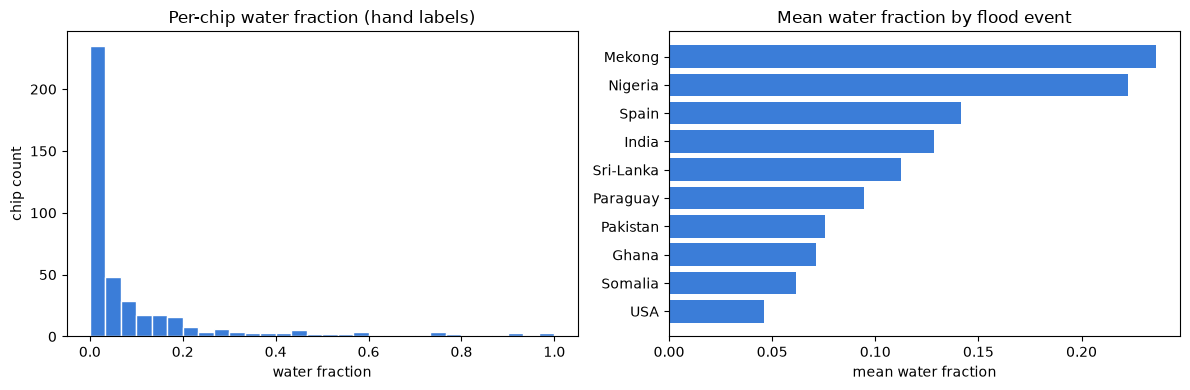

saved -> c:\Users\Soumyadip Nayak\Documents\Developer\SphoorthiQ\sphoorthq-geoverse\datasets\reports\03_eda_hand_labels.png


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(eda_df["water_fraction"].dropna(), bins=30, color="#3b7dd8", edgecolor="white")
axes[0].set_title("Per-chip water fraction (hand labels)")
axes[0].set_xlabel("water fraction")
axes[0].set_ylabel("chip count")

event_means = eda_df.groupby("event")["water_fraction"].mean().sort_values()
axes[1].barh(event_means.index, event_means.values, color="#3b7dd8")
axes[1].set_title("Mean water fraction by flood event")
axes[1].set_xlabel("mean water fraction")

plt.tight_layout()
eda_plot_path = os.path.join(REPORTS_DIR, "03_eda_hand_labels.png")
plt.savefig(eda_plot_path, dpi=110)
plt.show()
print(f"saved -> {eda_plot_path}")


## Custom train/test split (event-level holdout)

sen1floods11's own shipped split (`utils/ai/classic/sen1floods11_dataset.SPLITS_DIR`, downloaded in
notebook 01) partitions **per chip**, at random, stratified by event - every one of the 10 flood events
above appears in `train`, `valid`, *and* `test` (confirmed above: same event names, proportional counts in
each). Chips from the same event are geographically close and temporally correlated, so a per-chip split
lets the model see easy near-duplicates of its own test chips during training - an optimistic bias in the
reported metric, not a hard error, but a real one.

This project's own split instead holds out **entire flood events**: `Nigeria` and `Somalia` (the two
smallest events, chosen to keep the training pool large) go to `test` in full, never seen during training
or hyperparameter selection at all. The remaining 8 events are split chip-wise 85/15 into `train`/`valid`
(seeded, reproducible). Written to `datasets/processed/splits/flood_custom_{train,valid,test}_data.csv` -
same two-column format as the original, under `datasets/processed/` (a derived artifact) rather than
`datasets/raw/` (an untouched mirror of the source). `utils/ai/classic/sen1floods11_dataset.load_custom_split()`
reads it back with the same interface as the original `load_split()`.

Notebook `04` trains and tunes hyperparameters on this custom `train`/`valid`, and reports its confusion
matrix on this custom `test` - a genuinely unseen-event evaluation - **in addition to**, not instead of,
metrics on the original `valid` split (kept for continuity with every run already in the registry/Compare
page, which use that key).

In [6]:
import csv

from utils.ai.classic.sen1floods11_dataset import CUSTOM_SPLITS_DIR

HOLDOUT_EVENTS = ["Nigeria", "Somalia"]  # smallest two events by chip count - keeps the training pool large
CUSTOM_VALID_FRACTION = 0.15
SPLIT_SEED = 7


def _pairs(chip_ids) -> list[tuple[str, str]]:
    return [(f"{cid}_S1Hand.tif", f"{cid}_LabelHand.tif") for cid in sorted(chip_ids)]


with logger.stage("build_custom_split") as stage:
    pool = [r["chip_id"] for r in eda_records if r["event"] not in HOLDOUT_EVENTS]
    held_out = [r["chip_id"] for r in eda_records if r["event"] in HOLDOUT_EVENTS]

    rng = np.random.default_rng(SPLIT_SEED)
    pool = list(pool)
    rng.shuffle(pool)
    n_valid = int(len(pool) * CUSTOM_VALID_FRACTION)

    custom_splits = {
        "valid": _pairs(pool[:n_valid]),
        "train": _pairs(pool[n_valid:]),
        "test": _pairs(held_out),
    }

    CUSTOM_SPLITS_DIR.mkdir(parents=True, exist_ok=True)
    for name, pairs in custom_splits.items():
        with open(CUSTOM_SPLITS_DIR / f"flood_custom_{name}_data.csv", "w", newline="", encoding="utf-8") as f:
            csv.writer(f).writerows(pairs)

    stage.metrics = {
        "holdout_events": ",".join(HOLDOUT_EVENTS),
        "n_train": len(custom_splits["train"]),
        "n_valid": len(custom_splits["valid"]),
        "n_test": len(custom_splits["test"]),
    }

print(f"custom split written to {CUSTOM_SPLITS_DIR}")
for name, pairs in custom_splits.items():
    print(f"  {name:5s}: {len(pairs)} chips")


[03_feature_engineering] -> build_custom_split ...
[03_feature_engineering] <- build_custom_split [OK] 0.014s {'holdout_events': 'Nigeria,Somalia', 'n_train': 329, 'n_valid': 58, 'n_test': 44}
custom split written to C:\Users\Soumyadip Nayak\Documents\Developer\SphoorthiQ\sphoorthq-geoverse\datasets\processed\splits
  valid: 58 chips
  train: 329 chips
  test : 44 chips


In [7]:
logger.finalize()

[03_feature_engineering] run complete in 133.389s -> C:\Users\Soumyadip Nayak\Documents\Developer\SphoorthiQ\sphoorthq-geoverse\datasets\reports\runs\4568d795-366c-4e7b-8449-c1837b9a049c.json


'C:\\Users\\Soumyadip Nayak\\Documents\\Developer\\SphoorthiQ\\sphoorthq-geoverse\\datasets\\reports\\runs\\4568d795-366c-4e7b-8449-c1837b9a049c.json'